In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report


c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random_state = 42

In [3]:
df = pd.read_csv('../Milestone 3 EDA/credit_card_cleaned.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Baseline

In [4]:
X = df.drop(columns='Class')
y = df['Class']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Default settings on RF

In [6]:
# Train using optimal parameters
model = RandomForestClassifier(
    random_state=random_state,
    n_jobs=-1,
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred = model.predict(X_test)

In [8]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
baseline_model_report_df = classification_report(y_test, y_pred, output_dict=True)

### Class Weight Balanced

In [10]:
# Train using optimal parameters
model = RandomForestClassifier(
    class_weight='balanced',
    random_state=random_state,
    n_jobs=-1
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(X_test)

In [12]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [13]:
baseline_balanced_model_report_df = classification_report(y_test, y_pred, output_dict=True)

## Undersamplgin

In [14]:
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0]
len(fraud), len(non_fraud)

(492, 284315)

In [15]:
# Undersample majority class to a 1:10 ratio
non_fraud_downsampled = non_fraud.sample(n=len(fraud) * 10, random_state=random_state)
non_fraud_downsampled

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
138028,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
63099,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
73411,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
164247,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
148999,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249845,154606.0,-1.235823,-0.571536,1.620984,-2.648022,0.431772,1.315577,-0.258094,0.687327,-1.039031,...,0.163828,0.220473,-0.023553,-1.685719,0.301464,-0.260192,0.268870,0.102644,88.30,0
131485,79621.0,1.227929,0.065334,0.043523,0.109012,-0.394905,-1.307819,0.349677,-0.310790,-0.030846,...,-0.424623,-1.375408,0.178609,0.395001,0.078121,0.619247,-0.109945,0.009712,44.94,0
96599,65844.0,-0.878702,0.077973,0.345555,-1.646600,-0.090887,-0.930793,-0.136898,0.407723,-1.456907,...,0.367227,0.880295,-0.150938,0.039828,-0.197562,-0.330629,0.274606,0.090629,15.00,0
164556,116806.0,-1.296659,0.282590,1.651779,-1.503733,-1.575132,-0.079848,-0.673041,0.332639,0.226605,...,-0.141780,0.269977,-0.043272,-0.036735,-0.731235,0.545507,-0.173457,0.059645,45.51,0


In [16]:
# Combine and shuffle
df_reduced = pd.concat([fraud, non_fraud_downsampled]).sample(frac=1).reset_index(drop=True)
df_reduced

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,39225.0,-0.764015,0.981551,2.025548,-0.635078,0.172516,-0.600004,0.799055,0.045662,-0.869859,...,-0.157629,-0.607950,-0.201106,0.308954,0.187420,-0.006945,-0.017162,0.049818,1.98,0
1,44472.0,-0.343595,1.035378,0.381325,0.753110,-0.010659,-0.061422,0.393586,0.439276,-0.921654,...,0.206331,0.399977,-0.046590,-0.353342,-0.055287,-0.304016,-0.064456,-0.032168,54.52,0
2,141969.0,2.072272,-0.099074,-1.139337,0.387837,-0.127534,-1.144353,0.139354,-0.290243,0.645796,...,-0.306125,-0.777176,0.329456,-0.127397,-0.299729,0.207169,-0.074989,-0.062771,1.78,0
3,55176.0,0.593332,-1.127694,0.948762,0.811957,-1.261993,0.337996,-0.502005,0.277009,0.617443,...,0.336781,0.506979,-0.233707,0.282673,0.081636,0.546812,-0.035145,0.056234,269.00,0
4,78004.0,-0.810645,0.387032,2.591668,-1.919281,-0.532103,-0.477720,0.361597,0.049915,1.502128,...,-0.023663,0.368609,-0.322383,0.389629,0.402461,-0.773407,0.202300,-0.086920,1.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5407,95759.0,1.890770,0.491469,-0.487849,3.968411,0.476682,0.407469,-0.094107,-0.000324,0.480396,...,-0.048426,0.235185,0.046309,-0.412854,0.106755,0.060321,-0.060485,-0.071203,7.58,0
5408,167789.0,2.085181,-1.293753,-0.550829,-1.056104,-0.767637,0.638735,-1.345558,0.129526,0.418128,...,0.190734,0.530943,0.109534,-0.337149,-0.278032,-0.218910,0.032291,-0.026941,73.00,0
5409,67150.0,-1.824295,0.403327,-1.994122,2.756558,-3.139064,0.408185,-1.209045,1.095634,-1.447225,...,0.838760,0.341727,0.947506,-0.145493,0.049326,0.831065,0.332421,0.252713,489.71,1
5410,32745.0,-2.179135,0.020218,-2.182733,2.572046,-3.663733,0.081568,0.268049,0.660437,-2.374027,...,1.026421,0.299614,1.656800,0.328433,0.106457,0.691775,0.196779,0.241085,717.15,1


In [17]:
X = df_reduced.drop(columns='Class')
y = df_reduced['Class']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    stratify=y,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

In [19]:
cv = StratifiedKFold(n_splits=5)

### Recall as metric

In [20]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
    model = RandomForestClassifier(
        class_weight='balanced',
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_recall_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_recall_df)

[I 2026-04-15 11:35:25,758] A new study created in memory with name: no-name-09fb527a-8297-4ced-b7cb-5d591586672a
[I 2026-04-15 11:35:27,248] Trial 0 finished with value: 0.8427458617332035 and parameters: {'n_estimators': 14, 'max_depth': 7, 'min_samples_split': 5}. Best is trial 0 with value: 0.8427458617332035.
[I 2026-04-15 11:35:29,984] Trial 1 finished with value: 0.837682570593963 and parameters: {'n_estimators': 189, 'max_depth': 13, 'min_samples_split': 5}. Best is trial 0 with value: 0.8427458617332035.
[I 2026-04-15 11:35:32,525] Trial 2 finished with value: 0.837682570593963 and parameters: {'n_estimators': 182, 'max_depth': 28, 'min_samples_split': 7}. Best is trial 0 with value: 0.8427458617332035.
[I 2026-04-15 11:35:34,066] Trial 3 finished with value: 0.8351509250243427 and parameters: {'n_estimators': 192, 'max_depth': 2, 'min_samples_split': 4}. Best is trial 0 with value: 0.8427458617332035.
[I 2026-04-15 11:35:34,289] Trial 4 finished with value: 0.8402142161635833

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
23,23,0.857936,2026-04-15 11:35:44.502319,2026-04-15 11:35:44.846945,0 days 00:00:00.344626,4,9,75,COMPLETE
81,81,0.857936,2026-04-15 11:36:12.519965,2026-04-15 11:36:13.154327,0 days 00:00:00.634362,4,10,108,COMPLETE
41,41,0.857936,2026-04-15 11:35:52.477947,2026-04-15 11:35:52.853673,0 days 00:00:00.375726,4,9,77,COMPLETE
39,39,0.857936,2026-04-15 11:35:51.820902,2026-04-15 11:35:52.195608,0 days 00:00:00.374706,4,8,76,COMPLETE
80,80,0.857936,2026-04-15 11:36:11.897806,2026-04-15 11:36:12.519965,0 days 00:00:00.622159,4,10,109,COMPLETE


In [21]:
# Train using optimal parameters
model_1 = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=top_5_recall_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_recall_df.head(1)['params_max_depth'].item(),
    min_samples_split=top_5_recall_df.head(1)['params_min_samples_split'].item(),
    random_state=random_state
)
model_1.fit(X_train, y_train)

,n_estimators,75
,criterion,'gini'
,max_depth,4
,min_samples_split,9
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model_1.predict(X_test)

In [23]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       985
           1       0.89      0.89      0.89        98

    accuracy                           0.98      1083
   macro avg       0.94      0.94      0.94      1083
weighted avg       0.98      0.98      0.98      1083



In [24]:
recall_model_report_df = classification_report(y_test, y_pred, output_dict=True)

## F1 as metric

In [25]:
# Parameter tuning
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
    model = RandomForestClassifier(
        class_weight='balanced',
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

top_5_f1_df = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_f1_df)

[I 2026-04-15 11:36:23,358] A new study created in memory with name: no-name-ec6a73fc-514e-477d-9518-09bd9a0e1d2e
[I 2026-04-15 11:36:23,527] Trial 0 finished with value: 0.9047303261349283 and parameters: {'n_estimators': 14, 'max_depth': 10, 'min_samples_split': 9}. Best is trial 0 with value: 0.9047303261349283.
[I 2026-04-15 11:36:24,321] Trial 1 finished with value: 0.9077521496294269 and parameters: {'n_estimators': 182, 'max_depth': 3, 'min_samples_split': 3}. Best is trial 1 with value: 0.9077521496294269.
[I 2026-04-15 11:36:26,207] Trial 2 finished with value: 0.9048730913074765 and parameters: {'n_estimators': 199, 'max_depth': 27, 'min_samples_split': 6}. Best is trial 1 with value: 0.9077521496294269.
[I 2026-04-15 11:36:27,080] Trial 3 finished with value: 0.9078470208724732 and parameters: {'n_estimators': 98, 'max_depth': 9, 'min_samples_split': 10}. Best is trial 3 with value: 0.9078470208724732.
[I 2026-04-15 11:36:28,445] Trial 4 finished with value: 0.90755765506586

,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_min_samples_split,params_n_estimators,state
46,46,0.915562,2026-04-15 11:37:07.212014,2026-04-15 11:37:07.416430,0 days 00:00:00.204416,6,2,27,COMPLETE
75,75,0.914329,2026-04-15 11:37:31.762810,2026-04-15 11:37:32.865827,0 days 00:00:01.103017,6,3,177,COMPLETE
84,84,0.914329,2026-04-15 11:37:42.335091,2026-04-15 11:37:43.423843,0 days 00:00:01.088752,6,3,178,COMPLETE
32,32,0.914147,2026-04-15 11:36:53.022584,2026-04-15 11:36:54.038621,0 days 00:00:01.016037,6,3,137,COMPLETE
96,96,0.914118,2026-04-15 11:37:54.719478,2026-04-15 11:37:55.365975,0 days 00:00:00.646497,6,3,96,COMPLETE


In [26]:
# Train using optimal parameters
model_2 = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=top_5_f1_df.head(1)['params_n_estimators'].item(),
    max_depth=top_5_f1_df.head(1)['params_max_depth'].item(),
    min_samples_split=top_5_f1_df.head(1)['params_min_samples_split'].item(),
    random_state=random_state
)
model_2.fit(X_train, y_train)

,n_estimators,27
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model_2.predict(X_test)

In [28]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       985
           1       0.96      0.90      0.93        98

    accuracy                           0.99      1083
   macro avg       0.97      0.95      0.96      1083
weighted avg       0.99      0.99      0.99      1083



In [29]:
f1_model_report_df = classification_report(y_test, y_pred, output_dict=True)

### Analyze reports

In [30]:
# 2. Convert and transpose
recall_report_df = pd.DataFrame(recall_model_report_df).transpose()
f1_report_df = pd.DataFrame(f1_model_report_df).transpose()

# 3. Combine multiple reports (e.g., adding a 'Model' column for identification)
combined_df = pd.concat([recall_report_df, f1_report_df], keys=['CC RF optimized for Recall', 'CC RF optimized for F1'])

In [31]:
combined_df

precision    recall  f1-score  \
CC RF optimized for Recall 0              0.988832  0.988832  0.988832   
                           1              0.887755  0.887755  0.887755   
                           accuracy       0.979686  0.979686  0.979686   
                           macro avg      0.938294  0.938294  0.938294   
                           weighted avg   0.979686  0.979686  0.979686   
CC RF optimized for F1     0              0.989909  0.995939  0.992915   
                           1              0.956522  0.897959  0.926316   
                           accuracy       0.987073  0.987073  0.987073   
                           macro avg      0.973215  0.946949  0.959615   
                           weighted avg   0.986888  0.987073  0.986888   

                                             support  
CC RF optimized for Recall 0              985.000000  
                           1               98.000000  
                           accuracy         0.979686  
                           macro avg     1083.000000  
                           weighted avg  1083.000000  
CC RF optimized for F1     0              985.000000  
                           1               98.000000  
                           accuracy         0.987073  
                           macro avg     1083.000000  
                           weighted avg  1083.000000

In [32]:
# Recall model
importances = model_1.feature_importances_
feature_names = df.drop(columns='Class').columns
feature_imp_recall_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
feature_imp_recall_df

,Feature,Gini Importance
14,V14,0.215674
10,V10,0.158979
12,V12,0.112016
4,V4,0.102157
17,V17,0.093451
3,V3,0.084769
16,V16,0.053680
11,V11,0.046406
2,V2,0.028511
9,V9,0.017918


In [33]:
# Recall model
importances = model_2.feature_importances_
feature_names = df.drop(columns='Class').columns
feature_imp_f1_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
feature_imp_f1_df

,Feature,Gini Importance
14,V14,0.304237
17,V17,0.125709
3,V3,0.107898
4,V4,0.098771
10,V10,0.078910
12,V12,0.067481
16,V16,0.026660
2,V2,0.020407
21,V21,0.018920
9,V9,0.018104


## Multivariate

In [ ]:
V14	0.262059
V4	0.106912
V10	0.093380
V17	0.091772
V12	0.086796
V16	0.076890
V3	0.075675

In [34]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\seaborn\relational.py:456: RuntimeWarning: invalid value encountered in sqrt
  linewidth = .08 * np.sqrt(np.percentile(sizes, 10))
c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\seaborn\utils.py:868: RuntimeWarning: invalid value encountered in sqrt
  "markersize": np.sqrt(kws.pop("s", rc["lines.markersize"] ** 2)),


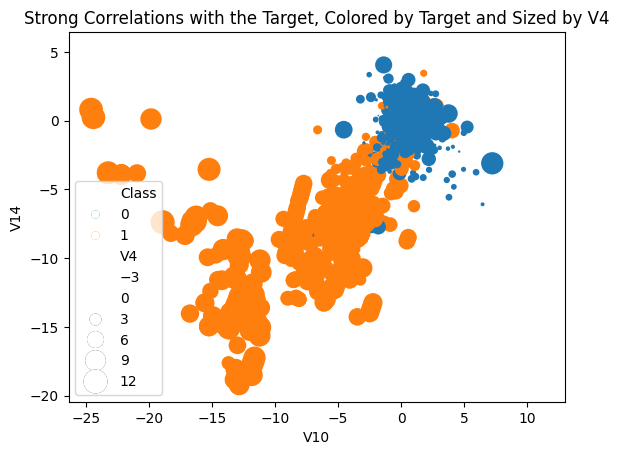

In [56]:
minroot = df_reduced['V4'].min()
maxroot = df_reduced['V4'].max()
maxbubble = 300
ax = sns.scatterplot(data = df_reduced, x = "V10", y = "V14", size = "V4", hue='Class', sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("V10")
ax.set_ylabel("V14")
plt.title("Strong Correlations with the Target, Colored by Target and Sized by V4")
plt.savefig('credit_card_figs/bubble_plot')
None

In [41]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       985
           1       0.77      0.90      0.83        98

    accuracy                           0.97      1083
   macro avg       0.88      0.94      0.91      1083
weighted avg       0.97      0.97      0.97      1083



In [ ]:
# model.feature_importances_

array([0.        , 0.00439951, 0.00186147, 0.00552418, 0.01274329,
       0.01031988, 0.00355872, 0.01981346, 0.        , 0.00186147,
       0.02303809, 0.00787362, 0.01125969, 0.00869856, 0.75808047,
       0.00634477, 0.00321786, 0.0666078 , 0.00398886, 0.00993867,
       0.        , 0.00264524, 0.00135277, 0.00546867, 0.0013961 ,
       0.01087407, 0.01343287, 0.        , 0.        , 0.00569993])

In [54]:
importances = model.feature_importances_
feature_names = df.drop(columns='Class').columns
feature_imp_f1_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
feature_imp_f1_df

,Feature,Gini Importance
14,V14,0.758080
17,V17,0.066608
10,V10,0.023038
7,V7,0.019813
26,V26,0.013433
4,V4,0.012743
12,V12,0.011260
25,V25,0.010874
5,V5,0.010320
19,V19,0.009939


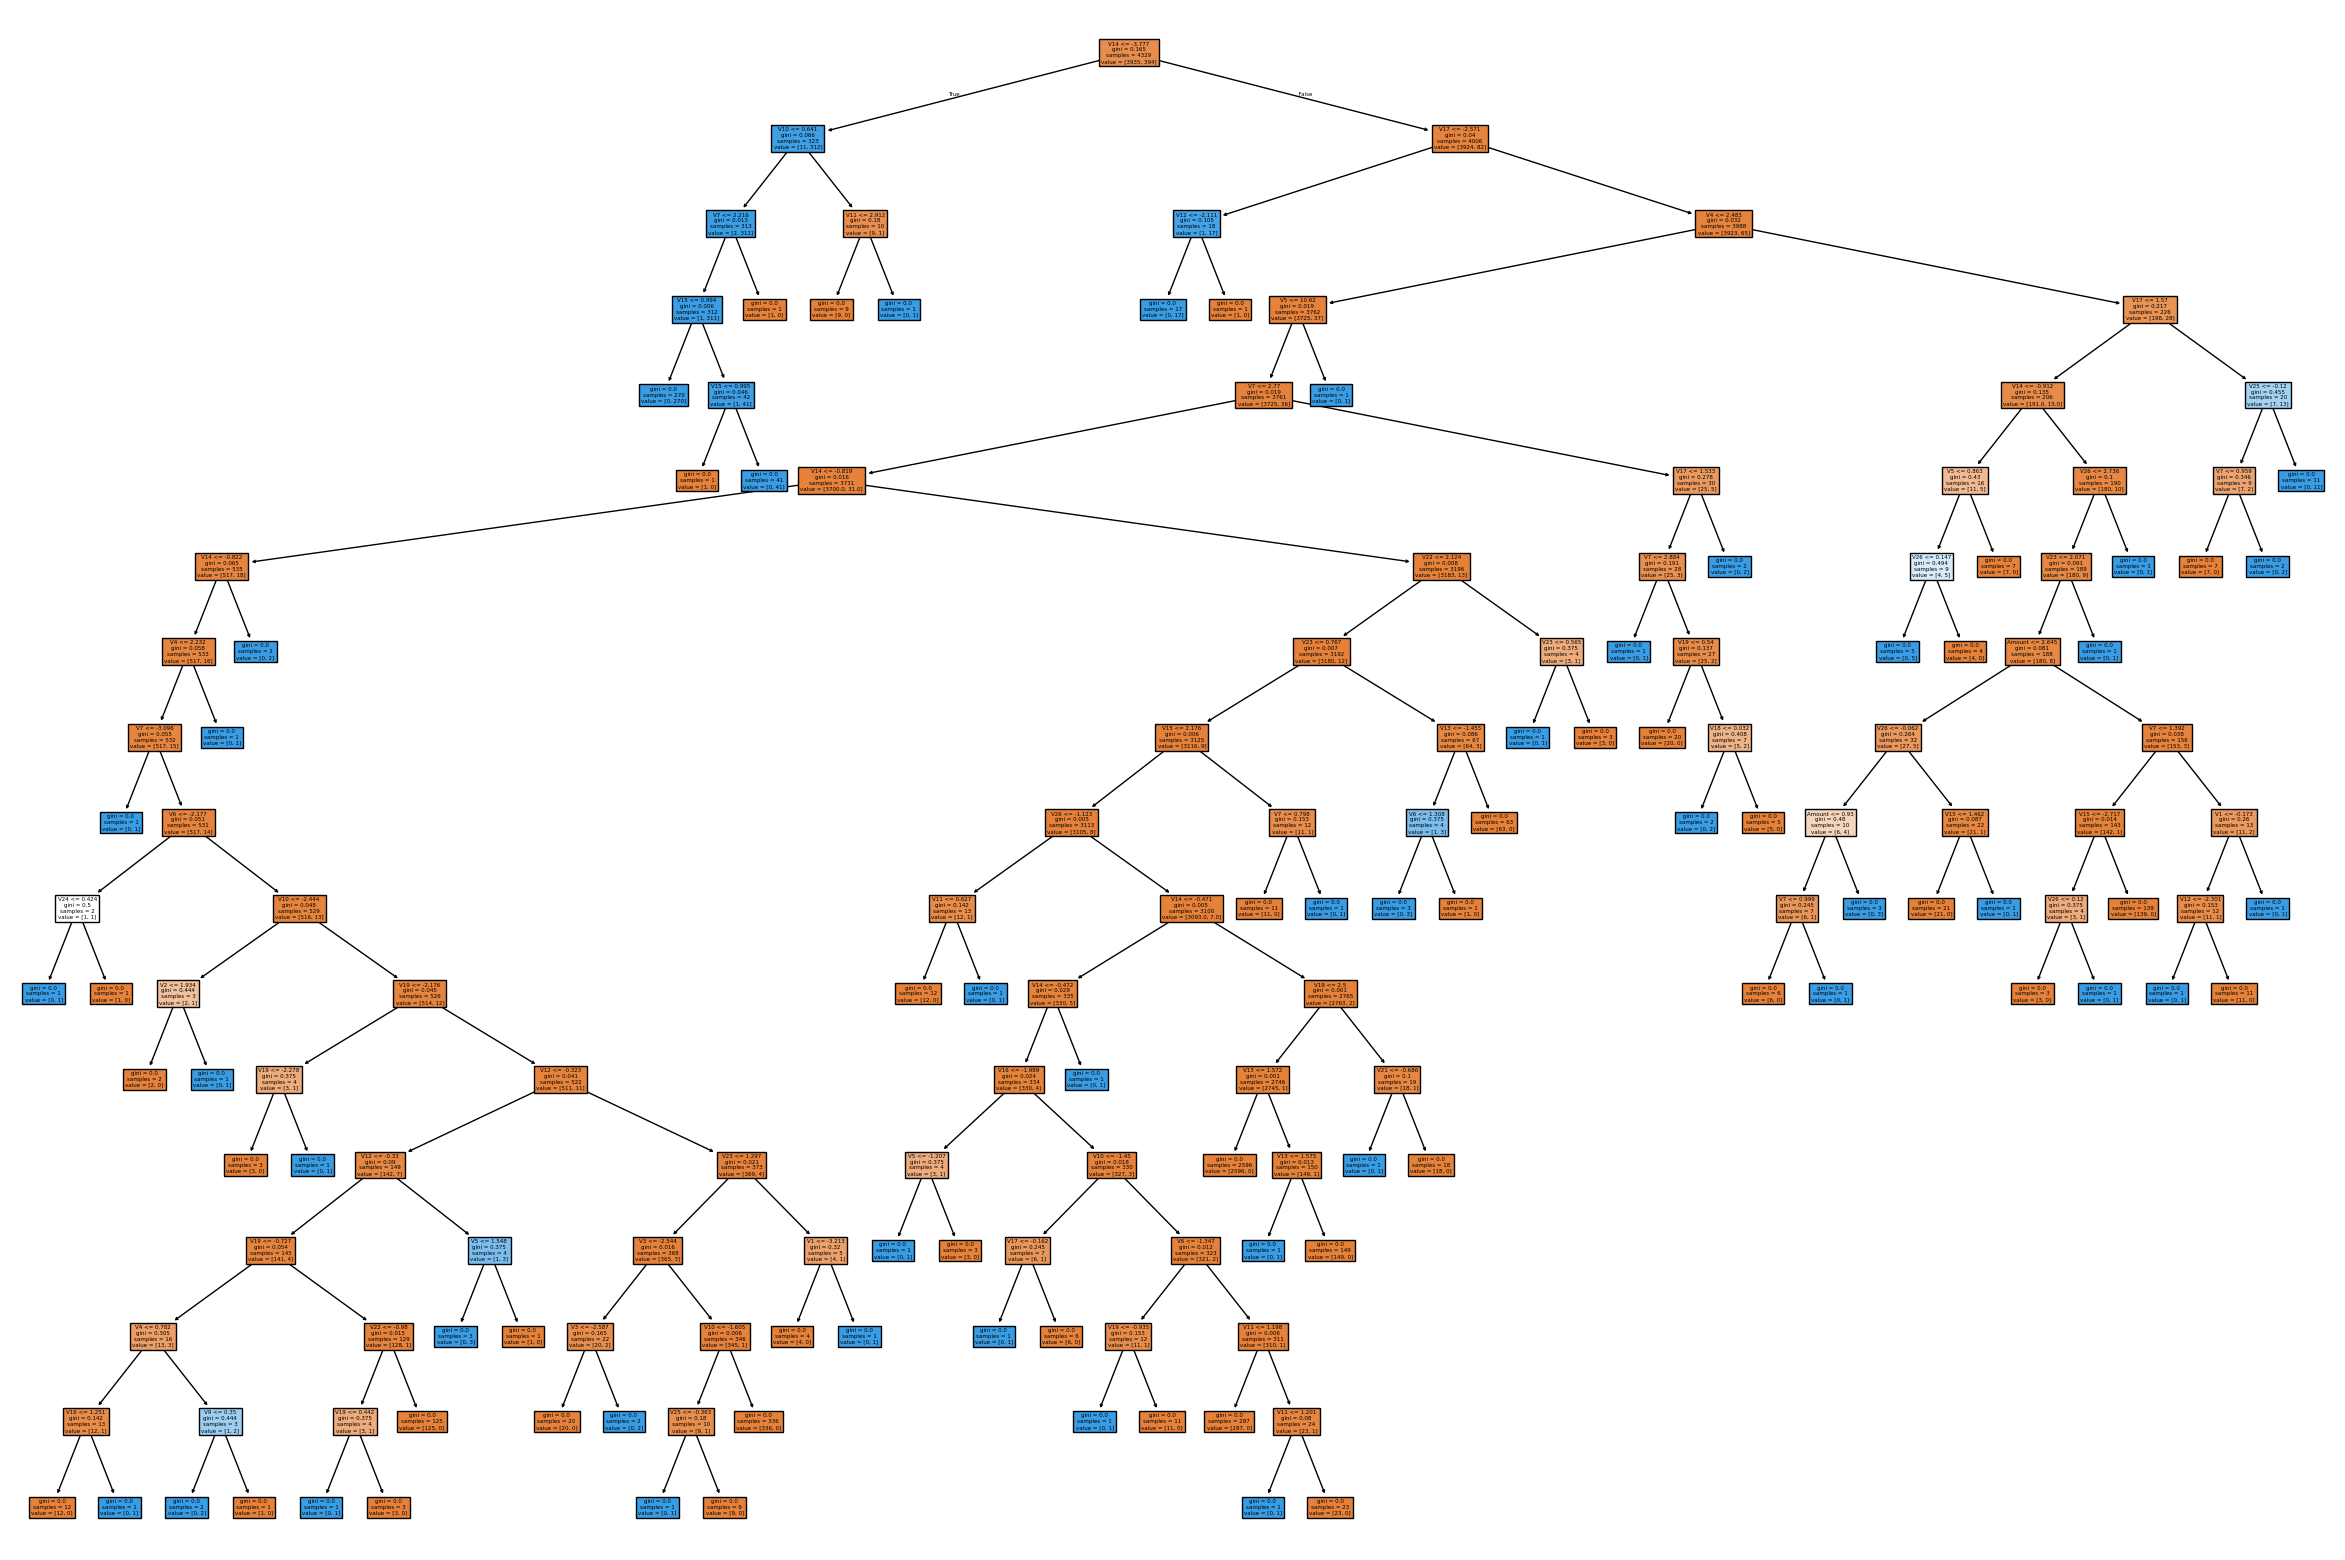

In [51]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 20))
tree.plot_tree(model, filled=True, feature_names=df_reduced.columns)
None